In [13]:
from torchvision.datasets.mnist import MNIST
from torch.utils.data.dataloader import DataLoader
from torchvision.transforms import ToTensor
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
# MNIST 다운로드 받아서 로컬에 저장 후 텐서 형태로 로드
train_data = MNIST(root="./data", train=True, download=True, transform=ToTensor())
test_data = MNIST(root="./data", train=False, download=True, transform=ToTensor())

In [ ]:
# 데이터 형태 확인
print(f"X_train data: {train_data.data.shape}")
print(f"y_train data: {train_data.targets}")
print(f"X_test data: {test_data.data.shape}")
print(f"y_test data: {test_data.targets}")

X_train data: torch.Size([60000, 28, 28])
y_train data: tensor([5, 0, 4,  ..., 5, 6, 8])
X_test data: torch.Size([10000, 28, 28])
y_test data: tensor([7, 2, 1,  ..., 4, 5, 6])


label: 5


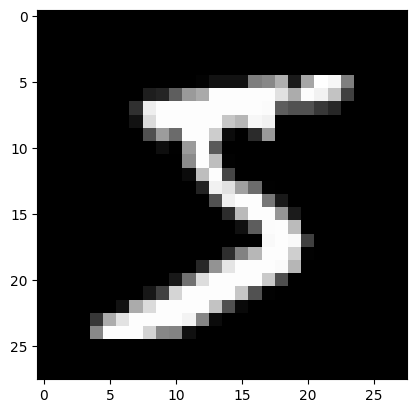

In [ ]:
# 시각화 해보기
idx_train = 0

print(f"label: {train_data.targets[idx_train]}")
plt.imshow(train_data.data[idx_train], cmap="gray")
plt.show()

In [ ]:
# 데이터로더로 맞춰줌
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

next(iter(train_loader))[0].shape       # 하나 꺼내서 보기.

torch.Size([256, 1, 28, 28])

In [ ]:
# 시퀀셜형태로 모델 빌드해보기.
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(64, 10),
)

model

Sequential(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# 클래스 형태로 모델 빌드 해보기.
class ClsModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()                  # 부모 클래스의 init을 먼저 불러온다
        self.fc1 = nn.Linear(784, 64)       # 입력 784, 출력 64 - Feature Extractor
        self.fc2 = nn.Linear(64, 32)        # 입력 64, 출력 32
        self.fc3 = nn.Linear(32, 10)        # 입력 32, 출력 10 - Classifier부분
    
    def forward(self, x):
        x = x.view(x.size(0), -1)           # 입력의 형태를 맞추기 위해 flatten해줌
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x
    
    
model = ClsModel()
model

ClsModel(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)

In [28]:
num_epochs = 20

lr = 1e-3

In [ ]:
criterion = nn.CrossEntropyLoss()                   # 분류 문제에서 CrossEntropyLoss를 사용한다.
optimizer = Adam(model.parameters(), lr=lr)         # 모델의 파라미터를 넣어줘야 한다.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)                                    # 모델을 gpu에 올려야 하는데 변수에 할당하지 않아도 된다.


ClsModel(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)

In [ ]:
loss_list = []

for ep in range(num_epochs):
    model.train()
    
    running_loss = 0.0                              # 에폭당 running_loss 초기화
    
    loop = tqdm(train_loader, leave=True)           # tqdm을 사용하여 진행상황을 시각화한다.
    
    for X, y in loop:                               # train_loader에서 배치만큼의 X, y를 뽑는다.
        X, y = X.to("cuda"), y.to("cuda")           # X, y를 gpu에 올린다.
        
        optimizer.zero_grad()                       # Adam 기울기를 초기화한다.
        
        logits = model(X)                           # Forward propagation
        
        loss = criterion(logits, y)                 # loss 구하기
        
        running_loss += loss.item()                 # loss 합하기
        
        loss.backward()                             # backpropagation
            
        optimizer.step()                            # 가중치 업데이트
        
        # tqdm progress bar에 현재 loss 표시
        loop.set_description(f"Epoch [{ep+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_loader)               # loss 평균 구하기
    print(f"\nEpoch {ep+1} 평균 Loss: {epoch_loss:.4f}")

Epoch [1/20]: 100%|██████████| 235/235 [00:13<00:00, 17.48it/s, loss=0.433]



Epoch 1 평균 Loss: 0.6857


Epoch [2/20]: 100%|██████████| 235/235 [00:13<00:00, 17.42it/s, loss=0.275]



Epoch 2 평균 Loss: 0.2684


Epoch [3/20]: 100%|██████████| 235/235 [00:13<00:00, 17.35it/s, loss=0.187]


...


Epoch 18 평균 Loss: 0.0457


Epoch [19/20]: 100%|██████████| 235/235 [00:12<00:00, 18.84it/s, loss=0.00672]



Epoch 19 평균 Loss: 0.0429


Epoch [20/20]: 100%|██████████| 235/235 [00:12<00:00, 18.82it/s, loss=0.00823]


Epoch 20 평균 Loss: 0.0387


In [ ]:
# 모델 추론모드 ( 가중치를 업데이트 하지 않게함 )
model.eval()

total = 0
correct = 0

# 모델 추론모드 ( gradient를 구하지 않음 )
with torch.no_grad():
    for X_test, y_test in test_loader:
        
        X_test, y_test = X_test.to(device), y_test.to(device)
        
        y_pred = model(X_test)
        
        #print(y_pred.shape)
        #print(y_test)
        
        val, y_pred = torch.max(y_pred, 1)          # 각 행별(1)로 최댓값 idx 반환 
        #print(y_pred)
        
        correct += (y_pred==y_test).sum().item()    # accuracy구하기
        total += (y_test.size(0))

correct/total

0.9726